In [ ]:
from __future__ import annotations

import os
import re
import warnings
from dataclasses import dataclass
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = False


## 1. Konfigurasi

In [ ]:
@dataclass
class Config:
    master_path: str = 'master_data.csv'
    threads_path: str = 'Threads_Diabetess.csv'
    x_path: str = 'X_Diabetes.csv'
    youtube_path: str = 'youtube_merged.csv'
    output_dir: str = 'output_diabetes_trend'


CONFIG = Config()
os.makedirs(CONFIG.output_dir, exist_ok=True)
print('Output folder:', CONFIG.output_dir)

Output folder: output_diabetes_trend


## 2. Fungsi bantu

In [ ]:
def save_fig(filename: str) -> str:
    path = os.path.join(CONFIG.output_dir, filename)
    plt.tight_layout()
    plt.savefig(path, dpi=170, bbox_inches='tight')
    return path


def clean_text(x) -> str:
    if pd.isna(x):
        return ''
    x = str(x).lower()
    x = re.sub(r'<br\s*/?>', ' ', x)
    x = re.sub(r'https?://\S+|www\.\S+', ' ', x)
    x = re.sub(r'[^\w\s]+', ' ', x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x


def print_section(title: str):
    print('\n' + '=' * 90)
    print(title)
    print('=' * 90)


## 3. Load data

In [ ]:
master_raw = pd.read_csv(CONFIG.master_path)
threads_raw = pd.read_csv(CONFIG.threads_path)
x_raw = pd.read_csv(CONFIG.x_path)
youtube_raw = pd.read_csv(CONFIG.youtube_path)

print('master_raw:', master_raw.shape)
print('threads_raw:', threads_raw.shape)
print('x_raw:', x_raw.shape)
print('youtube_raw:', youtube_raw.shape)


master_raw: (4116, 21)
threads_raw: (622, 4)
x_raw: (1519, 15)
youtube_raw: (1097, 11)


## 4. Data wrangling / cleaning

In [ ]:
def wrangle_master(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    for col in df.columns:
        if col != 'date':
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.drop_duplicates().sort_values('date').reset_index(drop=True)
    return df


def wrangle_threads(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['comment_clean'] = df['comment'].astype(str).map(clean_text)
    df = df.drop_duplicates().reset_index(drop=True)
    return df


def wrangle_x(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce', utc=True)
    for col in ['favorite_count', 'quote_count', 'reply_count', 'retweet_count']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df['text_clean'] = df['full_text'].astype(str).map(clean_text)
    df = df.drop_duplicates().reset_index(drop=True)
    return df


def wrangle_youtube(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['tanggal'] = pd.to_datetime(df['tanggal'], errors='coerce', utc=True)
    for col in ['like', 'reply_count', 'comment_length', 'engagement_score']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    if 'clean_comment' not in df.columns:
        df['clean_comment'] = df['comment'].astype(str).map(clean_text)
    else:
        df['clean_comment'] = df['clean_comment'].fillna('').astype(str).map(clean_text)
    df = df.drop_duplicates().reset_index(drop=True)
    return df


master = wrangle_master(master_raw)
threads = wrangle_threads(threads_raw)
x = wrangle_x(x_raw)
youtube = wrangle_youtube(youtube_raw)

print('master:', master.shape)
print('threads:', threads.shape)
print('x:', x.shape)
print('youtube:', youtube.shape)

master: (4116, 21)
threads: (589, 5)
x: (1519, 16)
youtube: (1097, 11)


## 5. Profiling data: Volume, Velocity, Variety, Veracity

In [ ]:
def dataset_profile(name: str, df: pd.DataFrame, datetime_col: str | None = None) -> Dict[str, object]:
    profile = {
        'dataset': name,
        'rows': df.shape[0],
        'cols': df.shape[1],
        'missing_cells': int(df.isna().sum().sum()),
        'missing_pct': float(df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100) if df.size else 0,
        'duplicate_rows': int(df.duplicated().sum()),
    }
    if datetime_col and datetime_col in df.columns:
        dt = pd.to_datetime(df[datetime_col], errors='coerce')
        profile['start_date'] = dt.min()
        profile['end_date'] = dt.max()
        profile['date_coverage_days'] = int((dt.max() - dt.min()).days) if pd.notna(dt.max()) and pd.notna(dt.min()) else None
        profile['unique_dates'] = int(dt.dt.date.nunique(dropna=True))
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    object_cols = df.select_dtypes(include='object').columns.tolist()
    datetime_cols = df.select_dtypes(include=['datetime64[ns]', 'datetime64[ns, UTC]']).columns.tolist()
    profile['numeric_cols'] = len(numeric_cols)
    profile['text_cols'] = len(object_cols)
    profile['datetime_cols'] = len(datetime_cols)
    return profile


profiles = [
    dataset_profile('master_data', master, 'date'),
    dataset_profile('Threads', threads, 'date'),
    dataset_profile('X', x, 'created_at'),
    dataset_profile('YouTube', youtube, 'tanggal'),
]

profile_table = pd.DataFrame(profiles)
profile_table

,dataset,rows,cols,missing_cells,missing_pct,duplicate_rows,start_date,end_date,date_coverage_days,unique_dates,numeric_cols,text_cols,datetime_cols
0,master_data,4116,21,0,0.000000,0,2015-01-01 00:00:00,2026-04-08 00:00:00,4115,4116,20,0,1
1,Threads,589,5,59,2.003396,0,2024-02-20 00:00:00,2026-03-27 00:00:00,766,49,0,4,1
2,X,1519,16,8907,36.648288,0,2016-01-31 22:49:17+00:00,2026-03-31 23:42:30+00:00,3712,86,9,6,1
3,YouTube,1097,11,3359,27.836248,0,2018-01-03 11:22:12+00:00,2026-04-06 17:54:13+00:00,3015,779,4,6,1


## 6. Statistik deskriptif

In [ ]:
def summarize_numeric(df: pd.DataFrame, exclude: List[str] | None = None) -> pd.DataFrame:
    exclude = exclude or []
    num = df.select_dtypes(include=np.number).drop(columns=[c for c in exclude if c in df.columns], errors='ignore')
    if num.empty:
        return pd.DataFrame()
    summary = num.describe().T
    summary['missing'] = num.isna().sum()
    summary['missing_pct'] = summary['missing'] / len(num) * 100
    return summary


master_summary = summarize_numeric(master, exclude=['date'])
master_summary.head(15).round(3)

,count,mean,std,min,25%,50%,75%,max,missing,missing_pct
diabetes,4116.0,74.369,10.310,34.0,67.0,74.0,82.0,100.0,0,0.0
sering haus,4116.0,0.088,0.443,0.0,0.0,0.0,0.0,6.0,0,0.0
sering buang air kecil,4116.0,6.177,2.755,0.0,5.0,6.0,8.0,19.0,0,0.0
badan lemas,4116.0,12.943,5.404,0.0,9.0,13.0,17.0,47.0,0,0.0
penglihatan kabur,4116.0,0.056,0.382,0.0,0.0,0.0,0.0,6.0,0,0.0
luka sulit sembuh,4116.0,0.057,1.048,0.0,0.0,0.0,0.0,35.0,0,0.0
gula darah tinggi,4116.0,29.737,24.578,0.0,5.0,31.0,50.0,100.0,0,0.0
cek gula darah,4116.0,12.347,13.170,0.0,0.0,5.0,24.0,78.0,0,0.0
diet diabetes,4116.0,0.897,3.825,0.0,0.0,0.0,0.0,46.0,0,0.0
obesitas,4116.0,41.986,21.959,0.0,26.0,43.0,57.0,100.0,0,0.0


## 7. Outlier detection (IQR)

In [ ]:
def detect_outliers_iqr(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    rows = []
    for col in cols:
        s = pd.to_numeric(df[col], errors='coerce').dropna()
        if s.empty:
            continue
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = ((s < lower) | (s > upper)).sum()
        rows.append({
            'column': col,
            'q1': q1,
            'q3': q3,
            'iqr': iqr,
            'lower': lower,
            'upper': upper,
            'outlier_count': int(outliers),
            'outlier_pct': float(outliers / len(s) * 100),
        })
    return pd.DataFrame(rows).sort_values('outlier_pct', ascending=False)


outlier_table = detect_outliers_iqr(master, [c for c in master.columns if c != 'date'])
outlier_table.head(15).round(3)

,column,q1,q3,iqr,lower,upper,outlier_count,outlier_pct
18,hiperglikemia,0.0,0.0,0.0,0.0,0.0,1001,24.320
2,sering buang air kecil,5.0,8.0,3.0,0.5,12.5,393,9.548
8,diet diabetes,0.0,0.0,0.0,0.0,0.0,307,7.459
1,sering haus,0.0,0.0,0.0,0.0,0.0,179,4.349
14,gagal ginjal,45.0,67.0,22.0,12.0,100.0,169,4.106
13,retinopati,0.0,0.0,0.0,0.0,0.0,110,2.672
4,penglihatan kabur,0.0,0.0,0.0,0.0,0.0,103,2.502
17,prediabetes,0.0,0.0,0.0,0.0,0.0,79,1.919
11,makanan manis,15.0,30.0,15.0,-7.5,52.5,72,1.749
5,luka sulit sembuh,0.0,0.0,0.0,0.0,0.0,28,0.680


## 8. Korelasi terhadap target `diabetes`

In [ ]:
def correlation_with_target(df: pd.DataFrame, target: str) -> pd.Series:
    num = df.select_dtypes(include=np.number)
    if target not in num.columns:
        return pd.Series(dtype=float)
    corr = num.corr(numeric_only=True)[target].drop(target).sort_values(ascending=False)
    return corr


corr = correlation_with_target(master, 'diabetes')
corr.head(15).round(3)

,diabetes
insulin,0.494
badan lemas,0.432
makanan manis,0.325
gula darah tinggi,0.323
neuropati,0.319
sering buang air kecil,0.308
gagal ginjal,0.308
cek gula darah,0.307
hiperglikemia,0.270
minuman manis,0.267


## 9. Analisis tren tahunan dan bulanan

In [ ]:
yearly = master.groupby(master['date'].dt.year)['diabetes'].mean()
monthly = master.groupby(master['date'].dt.month)['diabetes'].mean()

print('Tren tahunan:')
display(yearly.to_frame('avg_diabetes').round(3))

print('\nTren bulanan:')
display(monthly.to_frame('avg_diabetes').round(3))

Tren tahunan:


,avg_diabetes
date,
2015,68.397
2016,73.402
2017,72.074
2018,69.137
2019,74.008
2020,72.773
2021,74.726
2022,71.589
2023,75.134



Tren bulanan:


,avg_diabetes
date,
1,75.116
2,77.484
3,77.790
4,72.837
5,73.021
6,69.630
7,69.991
8,69.801
9,72.770


## 10. Analisis media sosial

Bagian ini melihat panjang teks, engagement, dan distribusi topik.

In [ ]:
threads_len = threads['comment'].astype(str).str.len()
x_len = x['full_text'].astype(str).str.len()
yt_likes = pd.to_numeric(youtube['like'], errors='coerce')

print('Threads length summary')
display(threads_len.describe().to_frame('threads_comment_length'))

print('\nX length summary')
display(x_len.describe().to_frame('x_text_length'))

print('\nYouTube like summary')
display(yt_likes.describe().to_frame('youtube_like'))

Threads length summary


,threads_comment_length
count,589.000000
mean,189.186757
std,145.865570
min,3.000000
25%,61.000000
50%,154.000000
75%,288.000000
max,684.000000



X length summary


,x_text_length
count,1519.000000
mean,122.447005
std,87.090663
min,11.000000
25%,51.500000
50%,90.000000
75%,182.500000
max,329.000000



YouTube like summary


,youtube_like
count,1097.000000
mean,2.398359
std,21.752274
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,565.000000


In [ ]:
topic_counts = youtube['video_topic'].value_counts()
topic_counts.to_frame('count')

,count
video_topic,
penjelasan_diabetes_mellitus,506
diabetes_mellitus_penjelasan_klinis,348
pencegahan_dan_penanganan_diabetes,158
jenis_diabetes_tipe1_dan_tipe2,84
diabetes_mellitus_gejala_penyebab,1


## 11. 5 Visualisasi utama

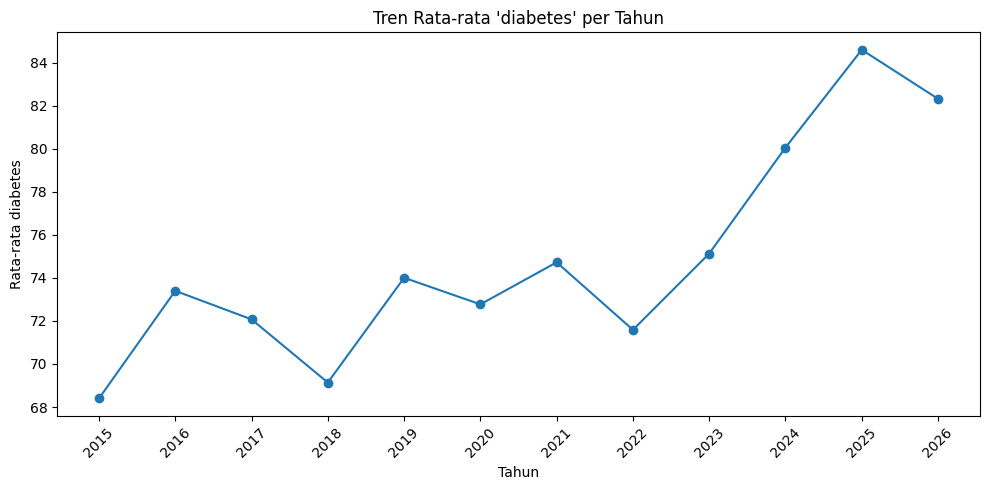

output_diabetes_trend/01_tren_diabetes_tahunan.png


In [ ]:
# 1. Tren rata-rata diabetes per tahun
plt.figure(figsize=(10, 5))
plt.plot(yearly.index, yearly.values, marker='o')
plt.title("Tren Rata-rata 'diabetes' per Tahun")
plt.xlabel('Tahun')
plt.ylabel('Rata-rata diabetes')
plt.xticks(yearly.index, rotation=45)
path1 = save_fig('01_tren_diabetes_tahunan.png')
plt.show()
print(path1)

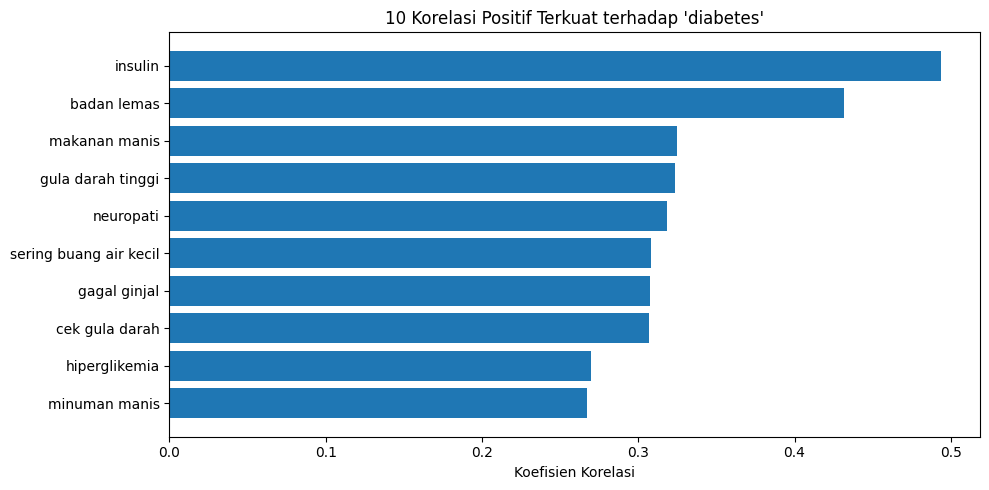

output_diabetes_trend/02_korelasi_diabetes.png


In [ ]:
# 2. Korelasi positif terkuat terhadap diabetes
top_corr = corr.head(10)
plt.figure(figsize=(10, 5))
plt.barh(top_corr.index[::-1], top_corr.values[::-1])
plt.title("10 Korelasi Positif Terkuat terhadap 'diabetes'")
plt.xlabel('Koefisien Korelasi')
path2 = save_fig('02_korelasi_diabetes.png')
plt.show()
print(path2)

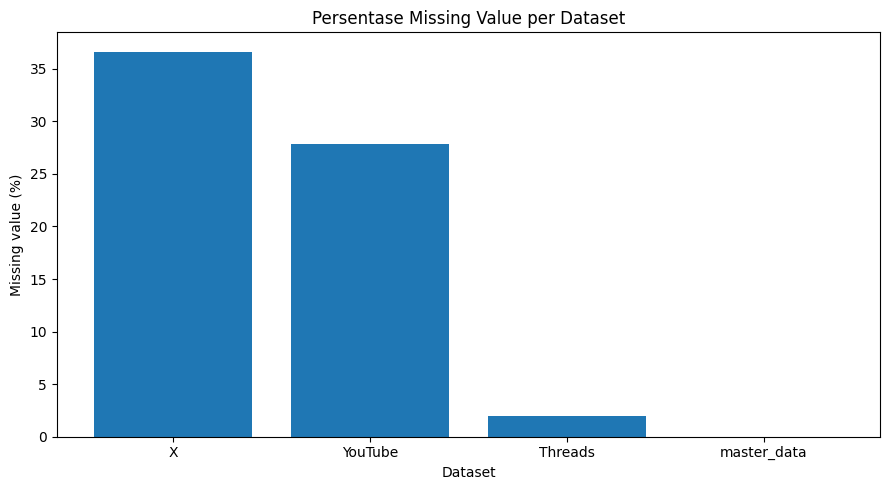

output_diabetes_trend/03_missingness_dataset.png


In [ ]:
# 3. Missing value per dataset
missing_df = pd.DataFrame(profiles)
plt.figure(figsize=(9, 5))
ordered = missing_df.sort_values('missing_pct', ascending=False)
plt.bar(ordered['dataset'], ordered['missing_pct'])
plt.title('Persentase Missing Value per Dataset')
plt.ylabel('Missing value (%)')
plt.xlabel('Dataset')
path3 = save_fig('03_missingness_dataset.png')
plt.show()
print(path3)

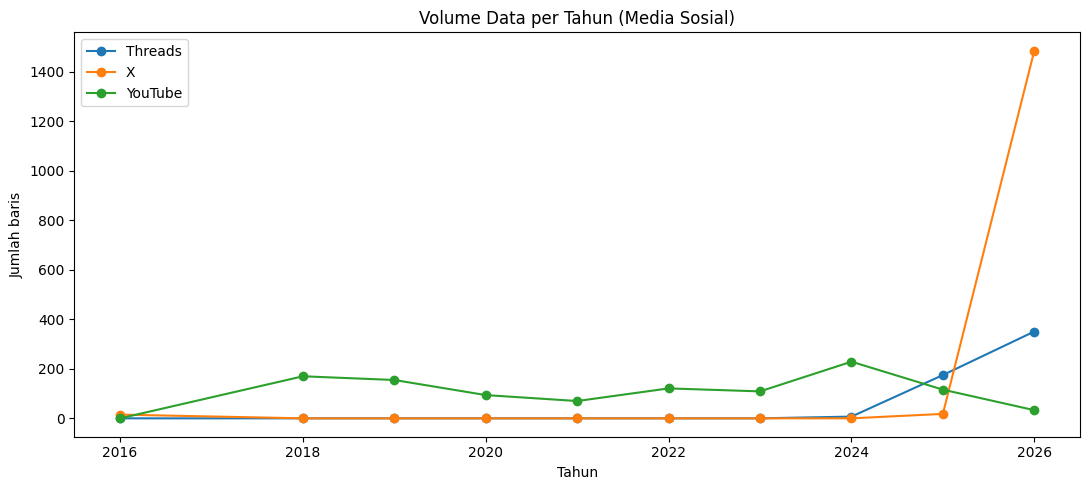

output_diabetes_trend/04_volume_media_sosial.png


In [ ]:
# 4. Volume data media sosial per tahun
threads_year = threads['date'].dt.year.value_counts().sort_index()
x_year = x['created_at'].dt.year.value_counts().sort_index()
yt_year = youtube['tanggal'].dt.year.value_counts().sort_index()

years = sorted(set(threads_year.index).union(x_year.index).union(yt_year.index))
vol = pd.DataFrame({'year': years})
vol['Threads'] = vol['year'].map(threads_year).fillna(0)
vol['X'] = vol['year'].map(x_year).fillna(0)
vol['YouTube'] = vol['year'].map(yt_year).fillna(0)

plt.figure(figsize=(11, 5))
plt.plot(vol['year'], vol['Threads'], marker='o', label='Threads')
plt.plot(vol['year'], vol['X'], marker='o', label='X')
plt.plot(vol['year'], vol['YouTube'], marker='o', label='YouTube')
plt.title('Volume Data per Tahun (Media Sosial)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah baris')
plt.legend()
path4 = save_fig('04_volume_media_sosial.png')
plt.show()
print(path4)

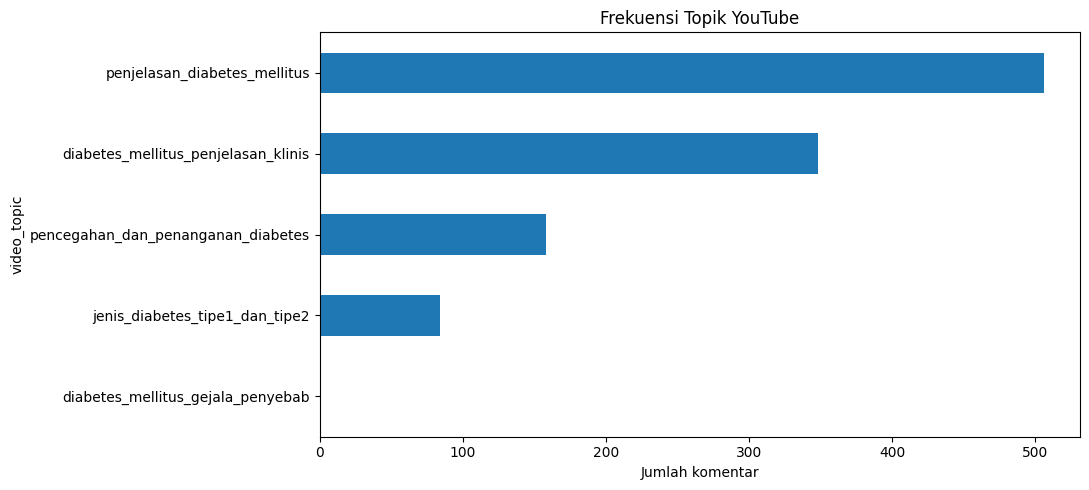

output_diabetes_trend/05_topik_youtube.png


In [ ]:
# 5. Frekuensi topik YouTube
plt.figure(figsize=(11, 5))
topic_counts.sort_values(ascending=True).plot(kind='barh')
plt.title('Frekuensi Topik YouTube')
plt.xlabel('Jumlah komentar')
path5 = save_fig('05_topik_youtube.png')
plt.show()
print(path5)

## 12. Generate insight otomatis

In [ ]:
def generate_insights(master: pd.DataFrame, threads: pd.DataFrame, x: pd.DataFrame, youtube: pd.DataFrame) -> str:
    lines = []
    yearly = master.groupby(master['date'].dt.year)['diabetes'].mean()
    month_avg = master.groupby(master['date'].dt.month)['diabetes'].mean()
    corr = correlation_with_target(master, 'diabetes')
    top_corr = corr.head(5)

    threads_len = threads['comment'].astype(str).str.len()
    x_len = x['full_text'].astype(str).str.len()
    yt_likes = pd.to_numeric(youtube['like'], errors='coerce')

    lines.append('RINGKASAN INSIGHT UTAMA')
    lines.append(f"- Rata-rata 'diabetes' naik dari {yearly.iloc[0]:.2f} (tahun {yearly.index.min()}) ke {yearly.iloc[-1]:.2f} (tahun {yearly.index.max()}).")
    lines.append(f"- Bulan tertinggi rata-rata 'diabetes' adalah {month_avg.idxmax()} dengan nilai {month_avg.max():.2f}.")
    lines.append(f"- Bulan terendah rata-rata 'diabetes' adalah {month_avg.idxmin()} dengan nilai {month_avg.min():.2f}.")
    lines.append('- Korelasi positif terkuat terhadap diabetes:')
    for k, v in top_corr.items():
        lines.append(f'  • {k}: {v:.3f}')
    lines.append('- Media sosial menunjukkan distribusi tidak merata; sedikit posting menghasilkan engagement sangat besar (heavy-tail).')
    lines.append(f"- Threads median panjang komentar: {threads_len.median():.0f} karakter.")
    lines.append(f"- X median panjang teks: {x_len.median():.0f} karakter.")
    lines.append(f"- YouTube median like: {yt_likes.median():.0f}, menunjukkan banyak konten rendah engagement namun ada outlier besar.")
    lines.append('- Kesimpulan metodologis: master_data paling kuat untuk tren kesehatan, media sosial paling kuat sebagai sinyal konteks publik.')
    lines.append('- Korelasi bukan sebab-akibat; ini sinyal pola, bukan diagnosis klinis.')
    return '\n'.join(lines)


insight_text = generate_insights(master, threads, x, youtube)
print(insight_text)

RINGKASAN INSIGHT UTAMA
- Rata-rata 'diabetes' naik dari 68.40 (tahun 2015) ke 82.33 (tahun 2026).
- Bulan tertinggi rata-rata 'diabetes' adalah 11 dengan nilai 81.45.
- Bulan terendah rata-rata 'diabetes' adalah 6 dengan nilai 69.63.
- Korelasi positif terkuat terhadap diabetes:
  • insulin: 0.494
  • badan lemas: 0.432
  • makanan manis: 0.325
  • gula darah tinggi: 0.323
  • neuropati: 0.319
- Media sosial menunjukkan distribusi tidak merata; sedikit posting menghasilkan engagement sangat besar (heavy-tail).
- Threads median panjang komentar: 154 karakter.
- X median panjang teks: 90 karakter.
- YouTube median like: 0, menunjukkan banyak konten rendah engagement namun ada outlier besar.
- Kesimpulan metodologis: master_data paling kuat untuk tren kesehatan, media sosial paling kuat sebagai sinyal konteks publik.
- Korelasi bukan sebab-akibat; ini sinyal pola, bukan diagnosis klinis.


## 13. Simpan laporan ringkasan

In [ ]:
report_path = os.path.join(CONFIG.output_dir, 'ringkasan_insight_diabetes.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write('DETEKSI DINI TREN DIABETES MELALUI ANALISIS BIG DATA MEDIA SOSIAL DAN QUERY PENCARIAN INTERNET\n')
    f.write('=' * 100 + '\n\n')
    f.write('PROFILE DATA\n')
    f.write(profile_table.to_string(index=False))
    f.write('\n\nSTATISTIK DESKRIPTIF MASTER DATA\n')
    f.write(master_summary.head(20).round(3).to_string())
    f.write('\n\nOUTLIER TABLE\n')
    f.write(outlier_table.head(20).round(3).to_string(index=False))
    f.write('\n\nKORELASI\n')
    f.write(corr.head(20).round(3).to_string())
    f.write('\n\nINSIGHT\n')
    f.write(insight_text)

print('Report saved to:', report_path)
print('Selesai. Semua output ada di folder:', CONFIG.output_dir)

Report saved to: output_diabetes_trend/ringkasan_insight_diabetes.txt
Selesai. Semua output ada di folder: output_diabetes_trend


In [ ]:
# ===============================
# AGREGASI TIME SERIES
# ===============================

# Master (Google Trends proxy)
master_ts = master.set_index("date")["diabetes"]

# Threads
threads_ts = threads.groupby("date").size()

# X
x_ts = x.groupby(x["created_at"].dt.date).size()

# YouTube
yt_ts = youtube.groupby(youtube["tanggal"].dt.date).size()

# Samakan index jadi datetime
threads_ts.index = pd.to_datetime(threads_ts.index)
x_ts.index = pd.to_datetime(x_ts.index)
yt_ts.index = pd.to_datetime(yt_ts.index)

# Gabungkan semua
df_ts = pd.DataFrame({
    "diabetes_trend": master_ts,
    "threads_volume": threads_ts,
    "x_volume": x_ts,
    "yt_volume": yt_ts
}).fillna(0)

df_ts.head()

,diabetes_trend,threads_volume,x_volume,yt_volume
2015-01-01,48,0.0,0.0,0.0
2015-01-02,48,0.0,0.0,0.0
2015-01-03,42,0.0,0.0,0.0
2015-01-04,53,0.0,0.0,0.0
2015-01-05,59,0.0,0.0,0.0


In [ ]:
# ===============================
# KORELASI ANTAR PLATFORM
# ===============================

corr_matrix = df_ts.corr()
corr_matrix

,diabetes_trend,threads_volume,x_volume,yt_volume
diabetes_trend,1.000000,0.051381,0.107200,0.047667
threads_volume,0.051381,1.000000,0.293247,-0.012817
x_volume,0.107200,0.293247,1.000000,0.013250
yt_volume,0.047667,-0.012817,0.013250,1.000000


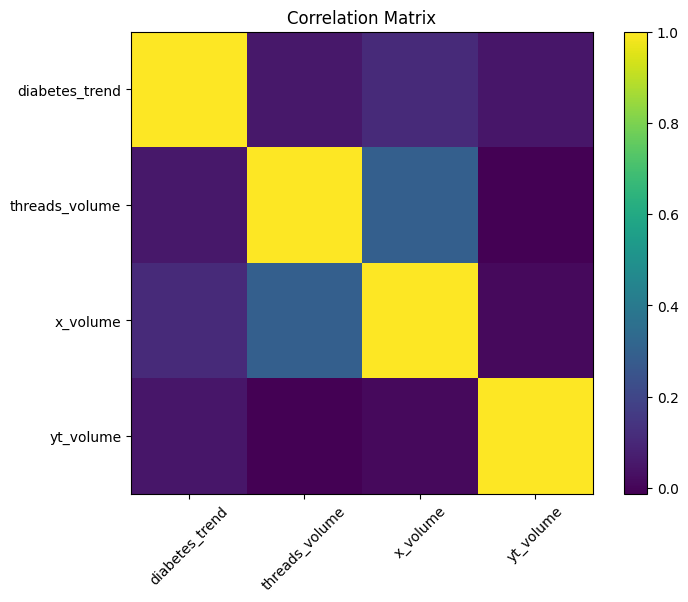

In [ ]:
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, interpolation='nearest')
plt.title("Correlation Matrix")
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.show()

In [ ]:
# ===============================
# LEAD-LAG ANALYSIS
# ===============================

def lag_correlation(series1, series2, max_lag=30):
    results = []

    for lag in range(-max_lag, max_lag + 1):
        if lag < 0:
            corr = series1.corr(series2.shift(-lag))
        else:
            corr = series1.shift(lag).corr(series2)

        results.append((lag, corr))

    return pd.DataFrame(results, columns=["lag", "correlation"])

# contoh: apakah Google Trends mendahului X?
lag_x = lag_correlation(df_ts["diabetes_trend"], df_ts["x_volume"])

lag_x.sort_values("correlation", ascending=False).head()

,lag,correlation
58,28,0.156900
60,30,0.156843
57,27,0.155905
59,29,0.155504
53,23,0.154166


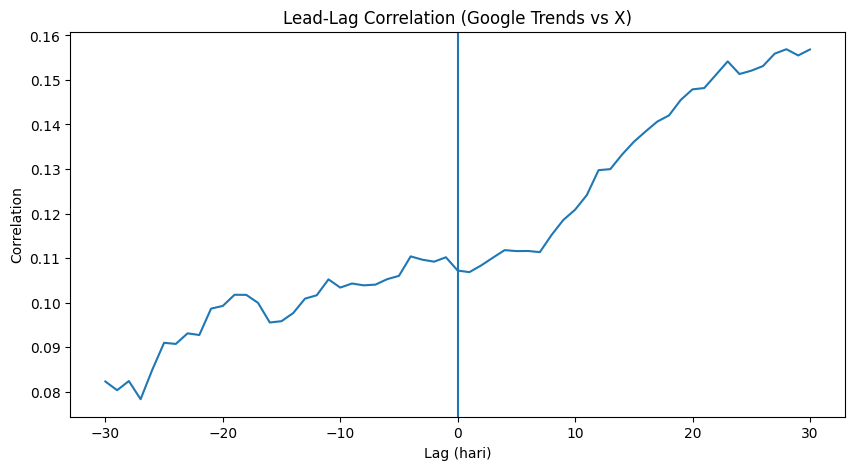

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(lag_x["lag"], lag_x["correlation"])
plt.title("Lead-Lag Correlation (Google Trends vs X)")
plt.xlabel("Lag (hari)")
plt.ylabel("Correlation")
plt.axvline(0)
plt.show()

In [ ]:
df_ts_diff = df_ts.diff().dropna()

In [ ]:
lag_x = lag_correlation(
    df_ts_diff["diabetes_trend"],
    df_ts_diff["x_volume"]
)

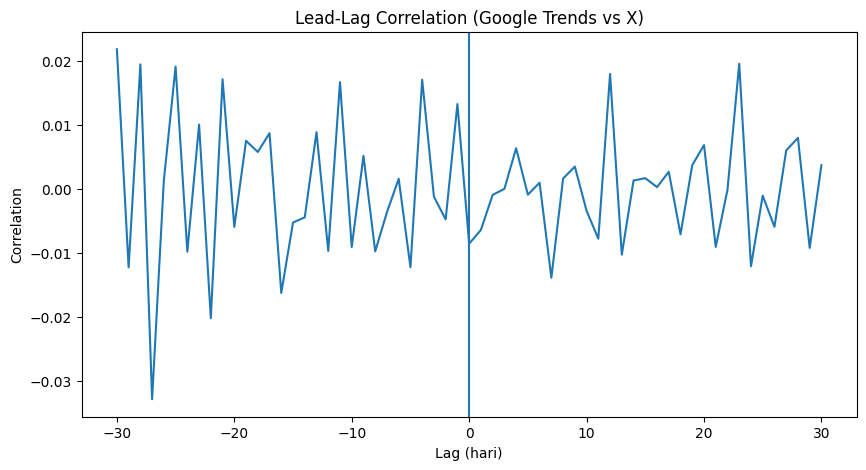

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(lag_x["lag"], lag_x["correlation"])
plt.title("Lead-Lag Correlation (Google Trends vs X)")
plt.xlabel("Lag (hari)")
plt.ylabel("Correlation")
plt.axvline(0)
plt.show()

<Figure size 1000x500 with 0 Axes>

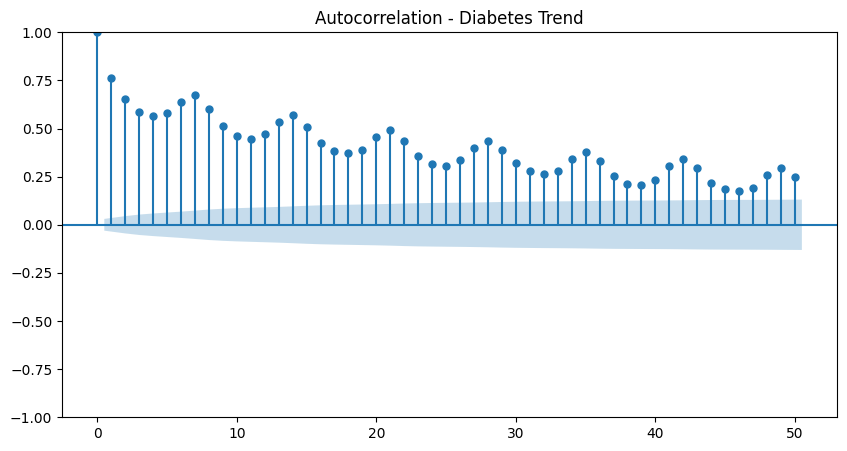

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,5))
plot_acf(master["diabetes"].dropna(), lags=50)
plt.title("Autocorrelation - Diabetes Trend")
plt.show()

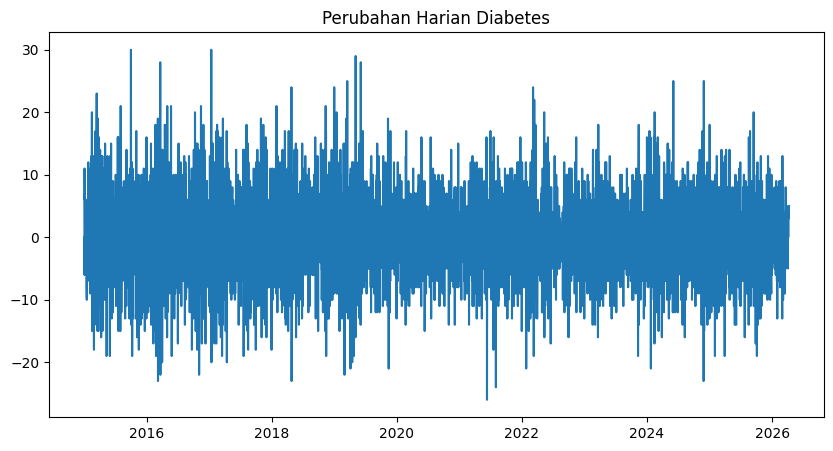

In [ ]:
df_ts["diabetes_diff"] = df_ts["diabetes_trend"].diff()

df_ts["diabetes_diff"].describe()

plt.figure(figsize=(10,5))
plt.plot(df_ts["diabetes_diff"])
plt.title("Perubahan Harian Diabetes")
plt.show()

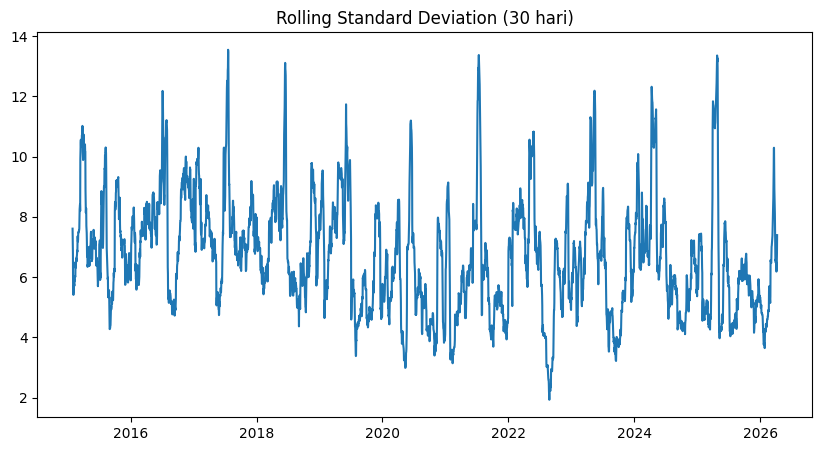

In [ ]:
rolling_std = df_ts["diabetes_trend"].rolling(window=30).std()

plt.figure(figsize=(10,5))
plt.plot(rolling_std)
plt.title("Rolling Standard Deviation (30 hari)")
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(master["diabetes"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -6.118514361183974
p-value: 8.972458853083177e-08


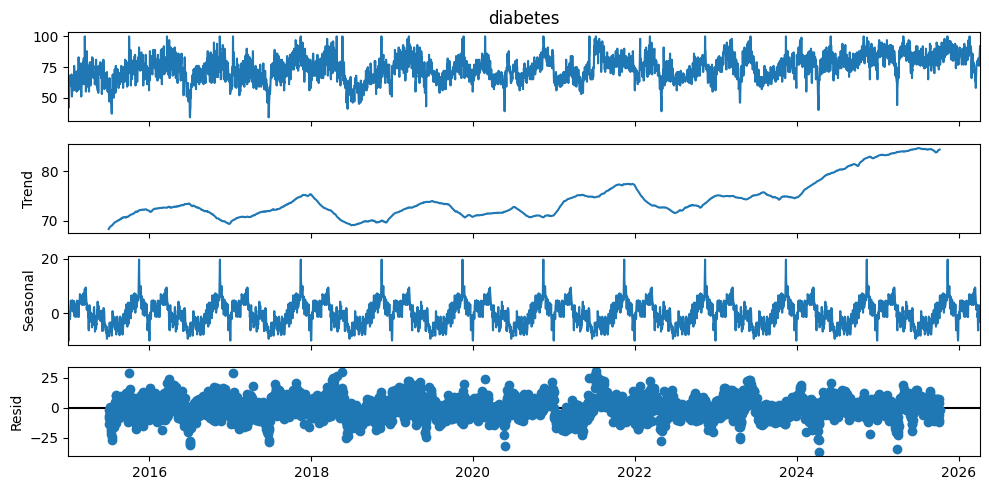

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(master.set_index("date")["diabetes"], model='additive', period=365)

decomp.plot()
plt.show()

Jumlah data: 4116
Periode: 2015-01-01 00:00:00 s/d 2026-04-08 00:00:00


<Figure size 1000x500 with 0 Axes>

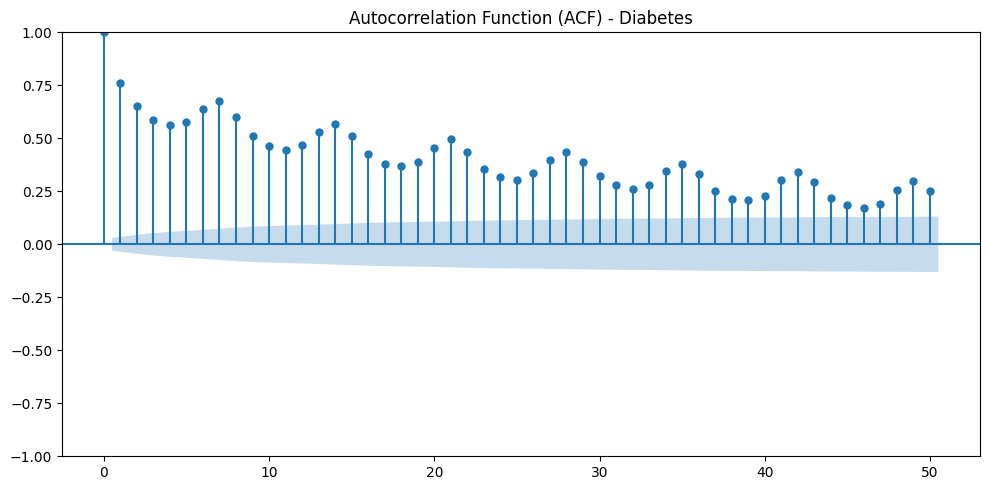

<Figure size 1000x500 with 0 Axes>

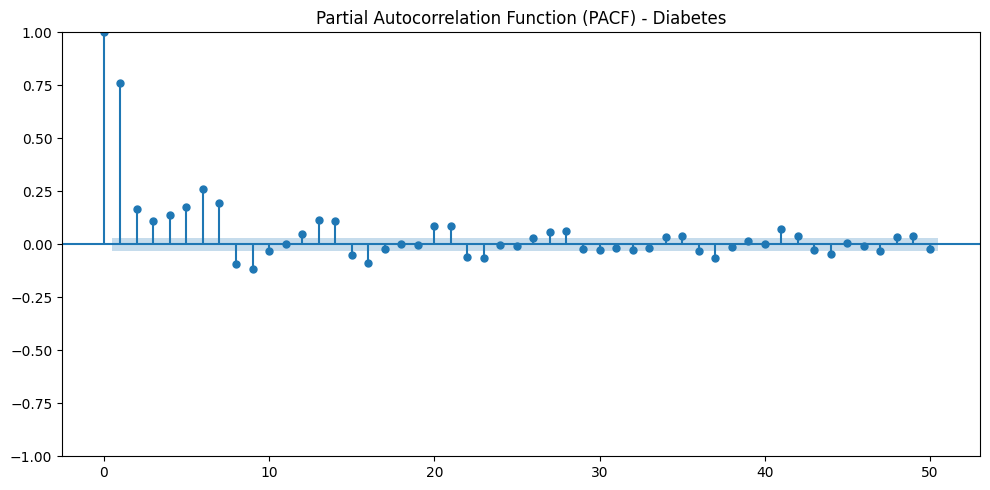


Statistik perubahan harian:
count    4115.000000
mean        0.010693
std         7.103026
min       -26.000000
25%        -5.000000
50%         0.000000
75%         4.000000
max        30.000000
Name: diabetes, dtype: float64


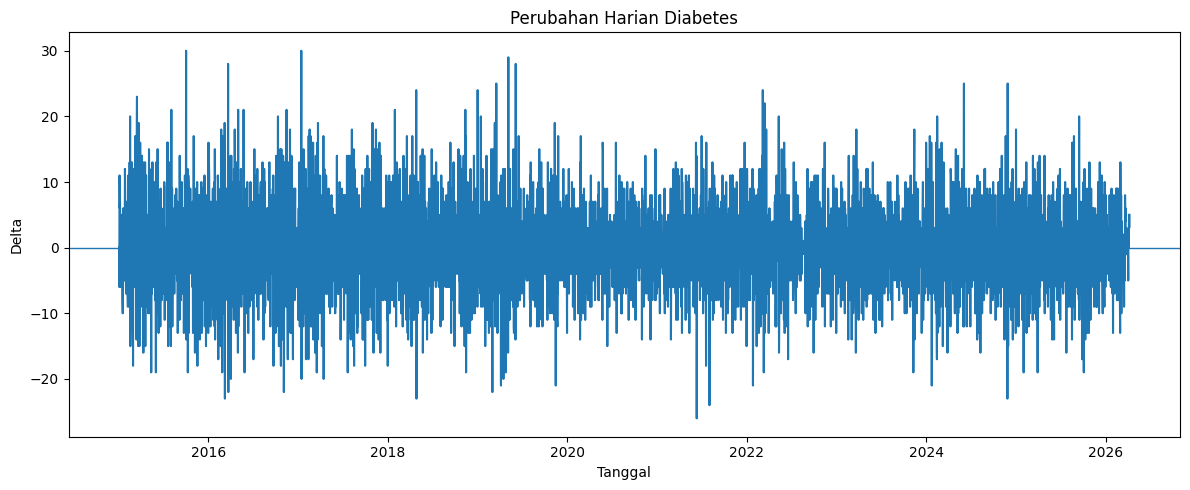

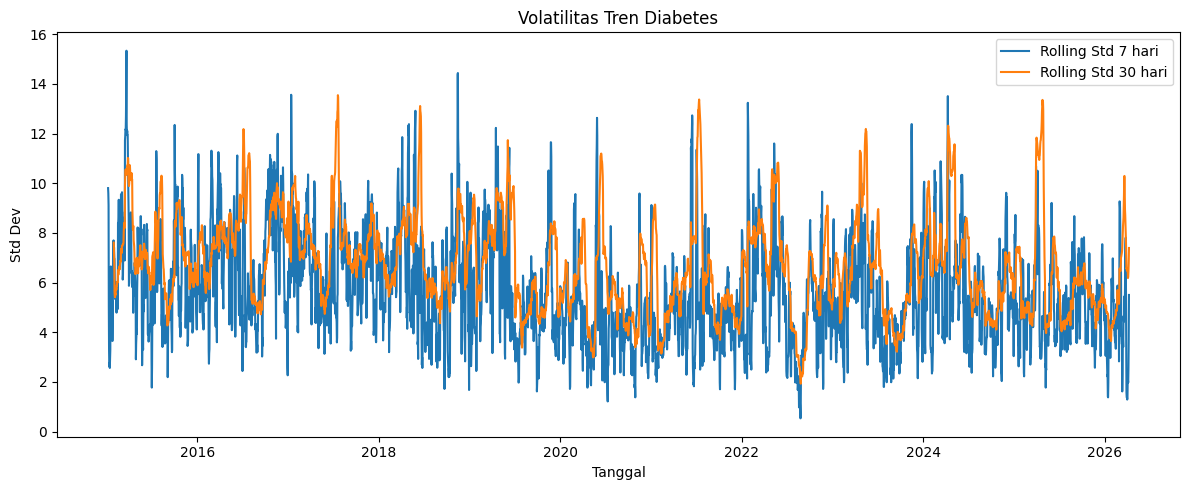


ADF Test
ADF Statistic: -6.1185
p-value: 0.0
Lags Used: 31
Observations Used: 4084
Kesimpulan: data cenderung stationary.


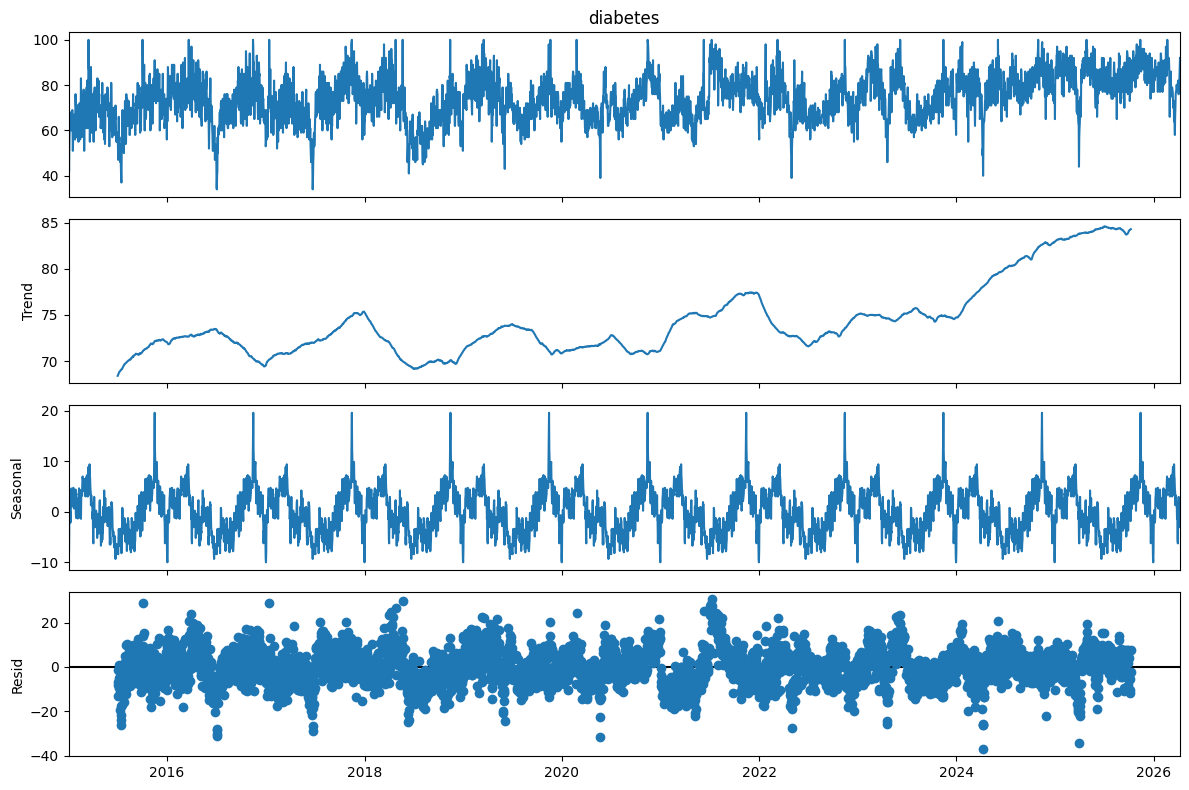

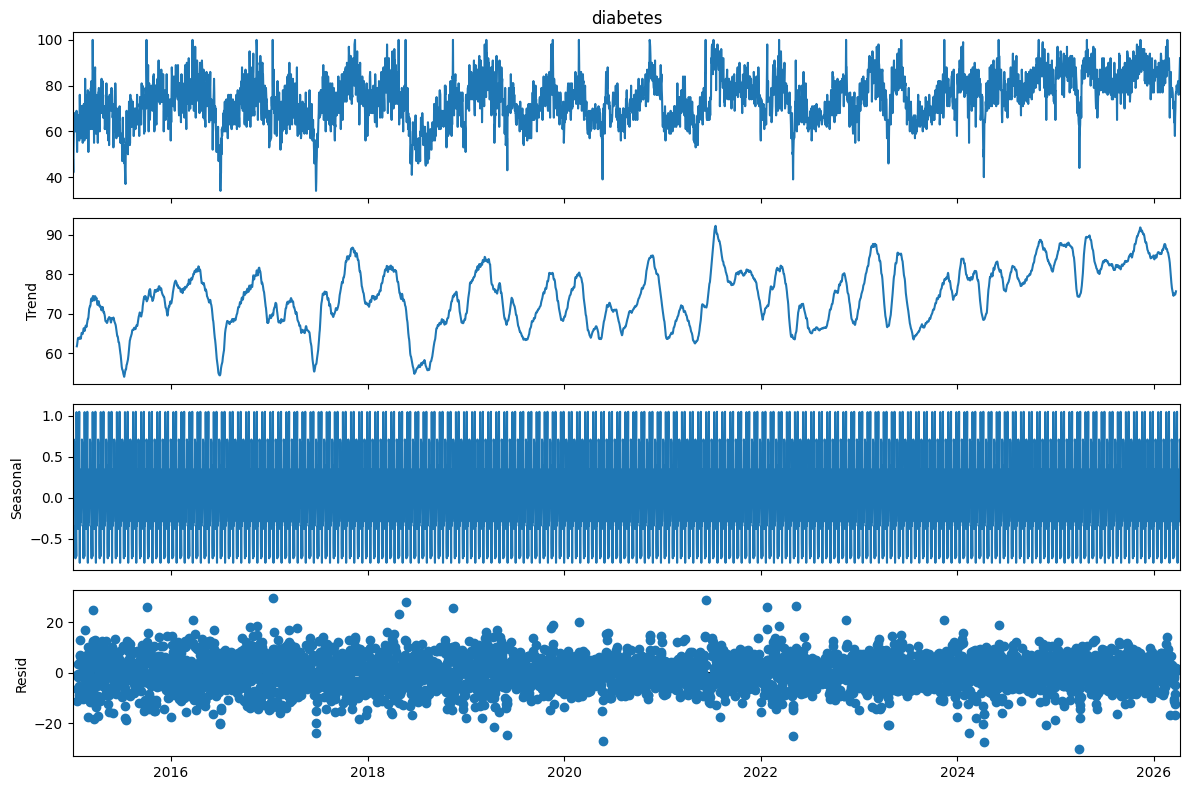


Ringkasan cepat:
- Autokorelasi lag 1 : 0.762
- Autokorelasi lag 7 : 0.679
- Autokorelasi lag 30: 0.324
- Rata-rata volatilitas perubahan harian: 7.103


In [ ]:
# =========================
# ANALISIS STRUKTUR TIME SERIES
# Fokus: autocorrelation, volatility, decomposition
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# -------------------------------------------------
# 1) Pastikan data sudah ada
#    master = dataframe yang punya kolom:
#    - date
#    - diabetes
# -------------------------------------------------
master["date"] = pd.to_datetime(master["date"], errors="coerce")
master = master.sort_values("date").reset_index(drop=True)

ts = master.set_index("date")["diabetes"].asfreq("D")
ts = ts.interpolate(limit_direction="both")

print("Jumlah data:", ts.shape[0])
print("Periode:", ts.index.min(), "s/d", ts.index.max())

# -------------------------------------------------
# 2) AUTOCORRELATION
# -------------------------------------------------
plt.figure(figsize=(10, 5))
plot_acf(ts, lags=50)
plt.title("Autocorrelation Function (ACF) - Diabetes")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plot_pacf(ts, lags=50, method="ywm")
plt.title("Partial Autocorrelation Function (PACF) - Diabetes")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 3) VOLATILITY
#    a) perubahan harian
#    b) rolling standard deviation
# -------------------------------------------------
ts_diff = ts.diff()

print("\nStatistik perubahan harian:")
print(ts_diff.describe())

plt.figure(figsize=(12, 5))
plt.plot(ts_diff)
plt.axhline(0, linewidth=1)
plt.title("Perubahan Harian Diabetes")
plt.xlabel("Tanggal")
plt.ylabel("Delta")
plt.tight_layout()
plt.show()

rolling_std_7 = ts.rolling(window=7).std()
rolling_std_30 = ts.rolling(window=30).std()

plt.figure(figsize=(12, 5))
plt.plot(rolling_std_7, label="Rolling Std 7 hari")
plt.plot(rolling_std_30, label="Rolling Std 30 hari")
plt.title("Volatilitas Tren Diabetes")
plt.xlabel("Tanggal")
plt.ylabel("Std Dev")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 4) ADF TEST (stationarity)
# -------------------------------------------------
adf_result = adfuller(ts.dropna())

print("\nADF Test")
print("ADF Statistic:", round(adf_result[0], 4))
print("p-value:", round(adf_result[1], 4))
print("Lags Used:", adf_result[2])
print("Observations Used:", adf_result[3])

if adf_result[1] < 0.05:
    print("Kesimpulan: data cenderung stationary.")
else:
    print("Kesimpulan: data cenderung non-stationary / memiliki tren.")

# -------------------------------------------------
# 5) DECOMPOSITION
#    Karena data harian, period umum = 365
#    Jika data terlalu pendek atau hasil terlalu kasar,
#    coba period=30 untuk pola bulanan.
# -------------------------------------------------
decomp = seasonal_decompose(ts, model="additive", period=365)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

# Alternatif decomposition bulanan
decomp_30 = seasonal_decompose(ts, model="additive", period=30)
fig = decomp_30.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 6) RINGKASAN INSIGHT OTOMATIS
# -------------------------------------------------
acf_top_lags = ts.autocorr(lag=1), ts.autocorr(lag=7), ts.autocorr(lag=30)

print("\nRingkasan cepat:")
print(f"- Autokorelasi lag 1 : {acf_top_lags[0]:.3f}")
print(f"- Autokorelasi lag 7 : {acf_top_lags[1]:.3f}")
print(f"- Autokorelasi lag 30: {acf_top_lags[2]:.3f}")
print(f"- Rata-rata volatilitas perubahan harian: {ts_diff.std():.3f}")

# -------------------------------------------------
# 7) SIMPAN HASIL GRAFIK JIKA PERLU
# -------------------------------------------------
# plt.savefig("nama_file.png", dpi=300, bbox_inches="tight")

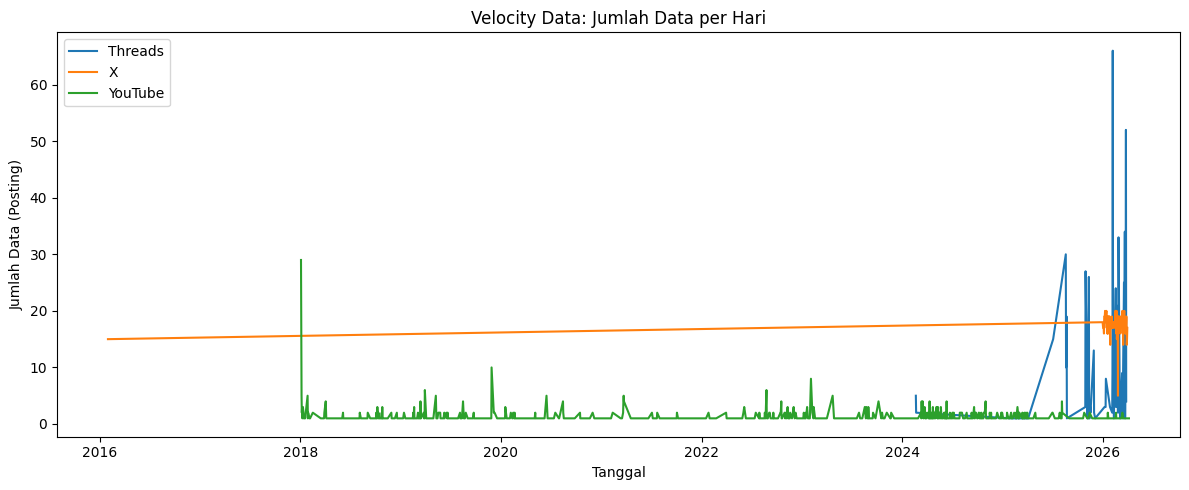

In [ ]:
# ===============================
# VELOCITY - DATA PER HARI
# ===============================

# Threads
threads_daily = threads.groupby("date").size()

# X
x_daily = x.groupby(x["created_at"].dt.date).size()
x_daily.index = pd.to_datetime(x_daily.index)

# YouTube
yt_daily = youtube.groupby(youtube["tanggal"].dt.date).size()
yt_daily.index = pd.to_datetime(yt_daily.index)

# Plot
plt.figure(figsize=(12,5))
plt.plot(threads_daily, label="Threads")
plt.plot(x_daily, label="X")
plt.plot(yt_daily, label="YouTube")

plt.title("Velocity Data: Jumlah Data per Hari")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Data (Posting)")
plt.legend()
plt.tight_layout()
plt.show()

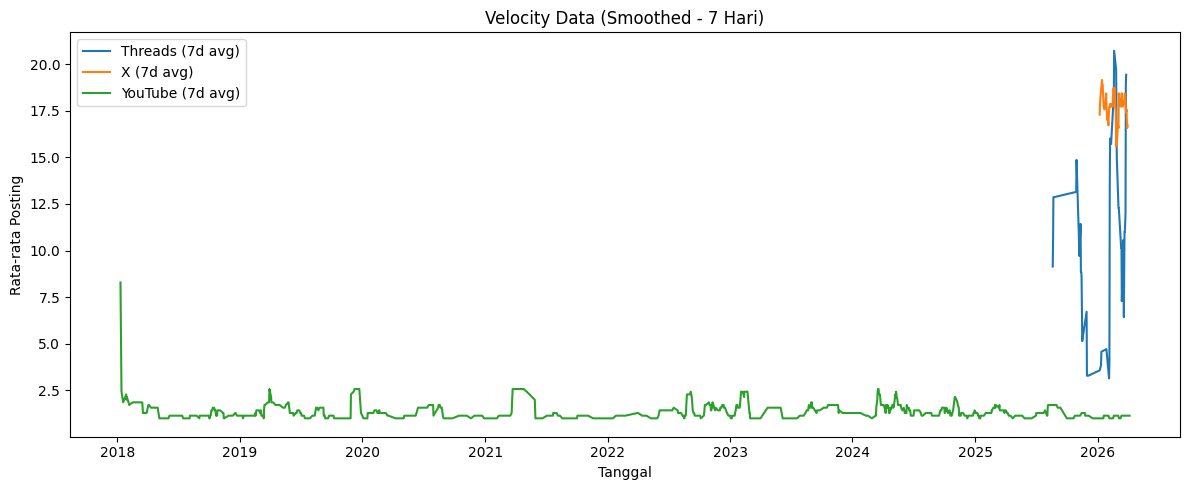

In [ ]:
# ===============================
# VELOCITY - SMOOTHING (7 HARI)
# ===============================

threads_smooth = threads_daily.rolling(7).mean()
x_smooth = x_daily.rolling(7).mean()
yt_smooth = yt_daily.rolling(7).mean()

plt.figure(figsize=(12,5))
plt.plot(threads_smooth, label="Threads (7d avg)")
plt.plot(x_smooth, label="X (7d avg)")
plt.plot(yt_smooth, label="YouTube (7d avg)")

plt.title("Velocity Data (Smoothed - 7 Hari)")
plt.xlabel("Tanggal")
plt.ylabel("Rata-rata Posting")
plt.legend()
plt.tight_layout()
plt.show()

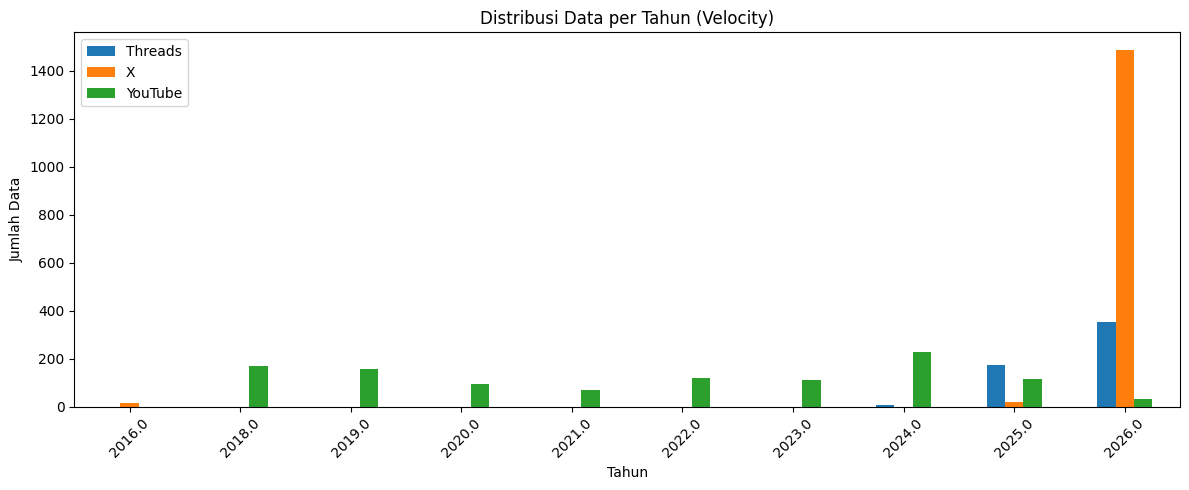

In [ ]:
# ===============================
# VELOCITY - DISTRIBUSI PER TAHUN
# ===============================

threads_year = threads["date"].dt.year.value_counts().sort_index()
x_year = x["created_at"].dt.year.value_counts().sort_index()
yt_year = youtube["tanggal"].dt.year.value_counts().sort_index()

df_year = pd.DataFrame({
    "Threads": threads_year,
    "X": x_year,
    "YouTube": yt_year
}).fillna(0)

df_year.plot(kind="bar", figsize=(12,5))

plt.title("Distribusi Data per Tahun (Velocity)")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ===============================
# VELOCITY - DENSITY / FREKUENSI
# ===============================

print("Threads rata-rata per hari:", threads_daily.mean())
print("X rata-rata per hari:", x_daily.mean())
print("YouTube rata-rata per hari:", yt_daily.mean())

Threads rata-rata per hari: 10.877551020408163
X rata-rata per hari: 17.662790697674417
YouTube rata-rata per hari: 1.4082156611039796


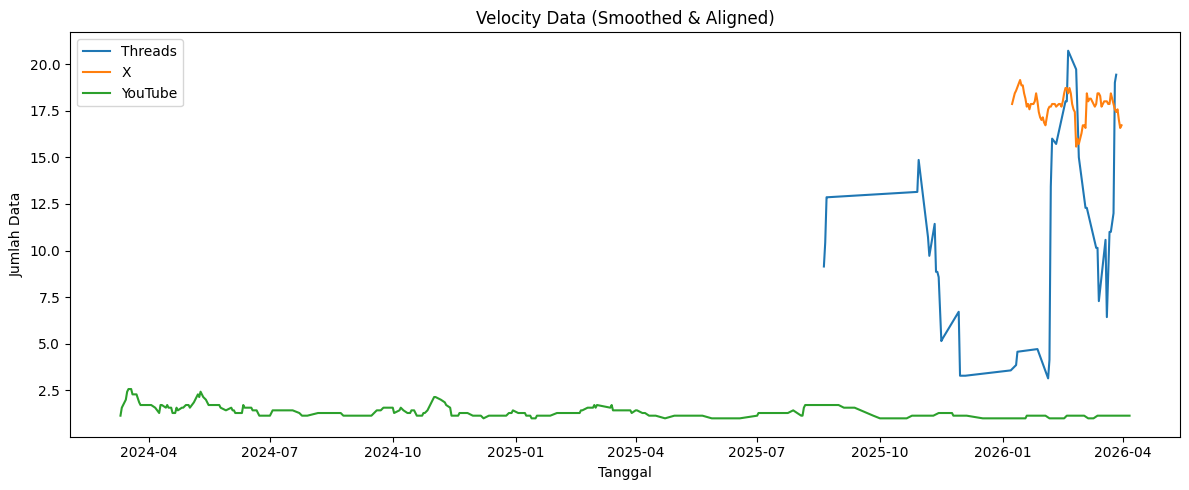

In [ ]:
# Filter periode yang sama
start_date = "2024-01-01"

threads_f = threads_daily[threads_daily.index >= start_date]
x_f = x_daily[x_daily.index >= start_date]
yt_f = yt_daily[yt_daily.index >= start_date]

# Smoothing
threads_s = threads_f.rolling(7).mean()
x_s = x_f.rolling(7).mean()
yt_s = yt_f.rolling(7).mean()

plt.figure(figsize=(12,5))
plt.plot(threads_s, label="Threads")
plt.plot(x_s, label="X")
plt.plot(yt_s, label="YouTube")

plt.title("Velocity Data (Smoothed & Aligned)")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Data")
plt.legend()
plt.tight_layout()
plt.show()

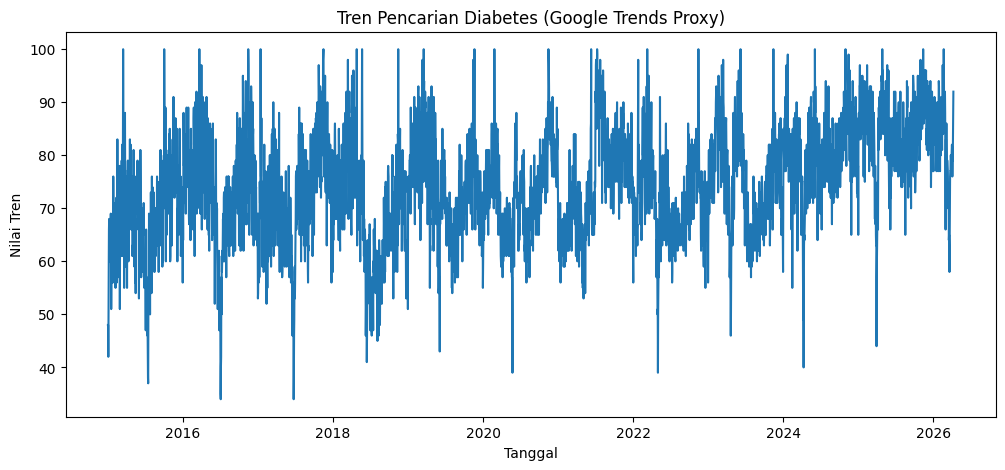

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(master["date"], master["diabetes"])
plt.title("Tren Pencarian Diabetes (Google Trends Proxy)")
plt.xlabel("Tanggal")
plt.ylabel("Nilai Tren")
plt.show()

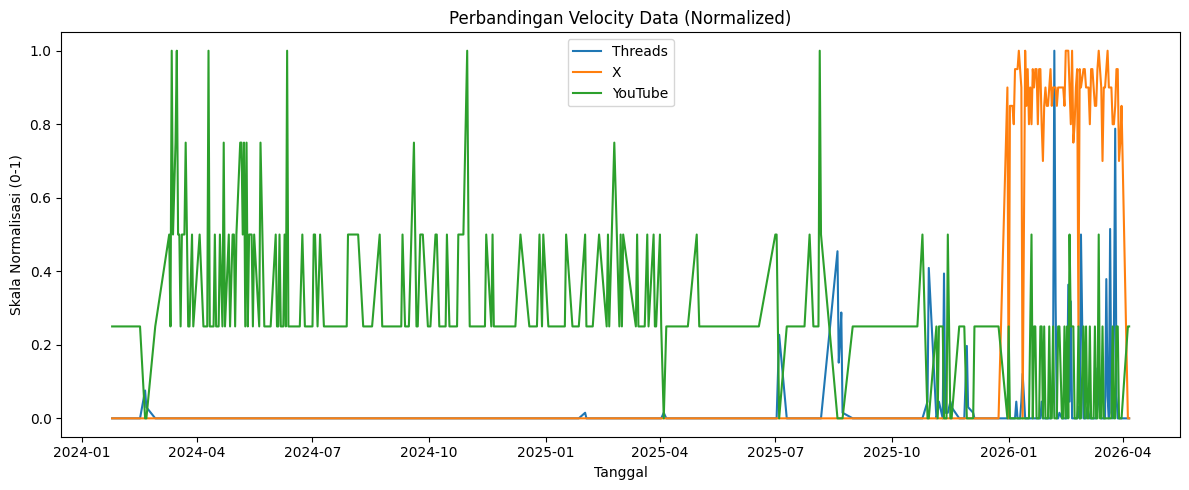

In [ ]:
# ===============================
# VELOCITY - NORMALIZED (0–1)
# ===============================

threads_daily = threads.groupby("date").size()
x_daily = x.groupby(x["created_at"].dt.date).size()
yt_daily = youtube.groupby(youtube["tanggal"].dt.date).size()

# Samakan index
x_daily.index = pd.to_datetime(x_daily.index)
yt_daily.index = pd.to_datetime(yt_daily.index)

df_daily = pd.DataFrame({
    "Threads": threads_daily,
    "X": x_daily,
    "YouTube": yt_daily
}).fillna(0)

# Fokus periode biar fair
df_daily = df_daily[df_daily.index >= "2024-01-01"]

# Normalisasi
df_norm = df_daily / df_daily.max()

plt.figure(figsize=(12,5))
plt.plot(df_norm["Threads"], label="Threads")
plt.plot(df_norm["X"], label="X")
plt.plot(df_norm["YouTube"], label="YouTube")

plt.title("Perbandingan Velocity Data (Normalized)")
plt.xlabel("Tanggal")
plt.ylabel("Skala Normalisasi (0-1)")
plt.legend()
plt.tight_layout()
plt.show()